# 04 — Headline comparison

Produces `figures/main_result.png`, the **verdict figure**: does this
replication reproduce the number the original claims? It puts our series
beside the trend the original reports, and compares the three headline
statistics directly.

## This is not the Figure 2 replica

Two different jobs, deliberately kept apart:

| Notebook | Figure | Question it answers |
|---|---|---|
| **04** (here) | `main_result.png` | *Did the number replicate?* Ours against the original's reported values. |
| **07** | `figure2_replica.png` | *Does it look like the paper's Fig. 2?* Same axes, same colours, both curves, ENSO shading. |
| **08** | `figure3_replica.png` | The same, for the paper's Fig. 3. |

A comparison figure and a replica are answering different questions, and one
cannot do both: this one shows a line the paper does not plot (the original's
stated 25→55 trend) so the two can be judged against each other, while the
replica shows only what the paper shows so the two can be laid side by side.

For the ENSO-removed series — the red line of the original Figure 2 — see
notebook 07. It is reproduced there in full.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
TARGET_RES_DEG = float(os.environ.get("MHW_TARGET_RES_DEG", 1.0))
LON_BAND_STRIDE = int(os.environ.get("MHW_LON_BAND_STRIDE", 8))
PERIOD_END = os.environ.get("MHW_PERIOD_END", "2016-12-31")
RESULTS_DIR = Path("../results")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# The configuration the replication's reported result was produced with: full
# global coverage at 1°, over Oliver et al.'s complete satellite record.
# CI runs the same code over a coarse grid to prove it still works, and any
# other configuration is a partial run whose numbers are NOT the result. Such a
# run must never overwrite figures/main_result.png or be mistakable for it, so
# it is written under a self-describing name and stamped on the face.
FULL_CONFIG = (1.0, 1, "2016-12-31")
IS_FULL_REPLICATION = (TARGET_RES_DEG, LON_BAND_STRIDE, PERIOD_END) == FULL_CONFIG
FIG_PATH = FIG_DIR / (
    "main_result.png" if IS_FULL_REPLICATION
    else f"partial_run_{TARGET_RES_DEG:g}deg_stride{LON_BAND_STRIDE}.png"
)
if not IS_FULL_REPLICATION:
    print(
        f"NOT the full replication configuration "
        f"({TARGET_RES_DEG:g}° grid, stride {LON_BAND_STRIDE}, to {PERIOD_END}; "
        f"full = 1° / stride 1 / to 2016-12-31).\n"
        f"These numbers do not reproduce the paper's statistic. "
        f"Writing {FIG_PATH.name} instead of main_result.png."
    )

_tag = f"partial_run_{TARGET_RES_DEG:g}deg_stride{LON_BAND_STRIDE}"
ANNUAL_PATH = RESULTS_DIR / (
    f"mhw_annual_{TARGET_RES_DEG:g}deg.nc" if IS_FULL_REPLICATION
    else f"{_tag}_annual.nc"
)
CMP_PATH = RESULTS_DIR / (
    "headline_comparison.json" if IS_FULL_REPLICATION
    else f"{_tag}_comparison.json"
)

res = xr.open_dataset(ANNUAL_PATH)
with open(CMP_PATH) as f:
    cmp = json.load(f)

years = res.year.values
days = res["global_mhw_days"].values

## The verdict: our series against the original's reported trend

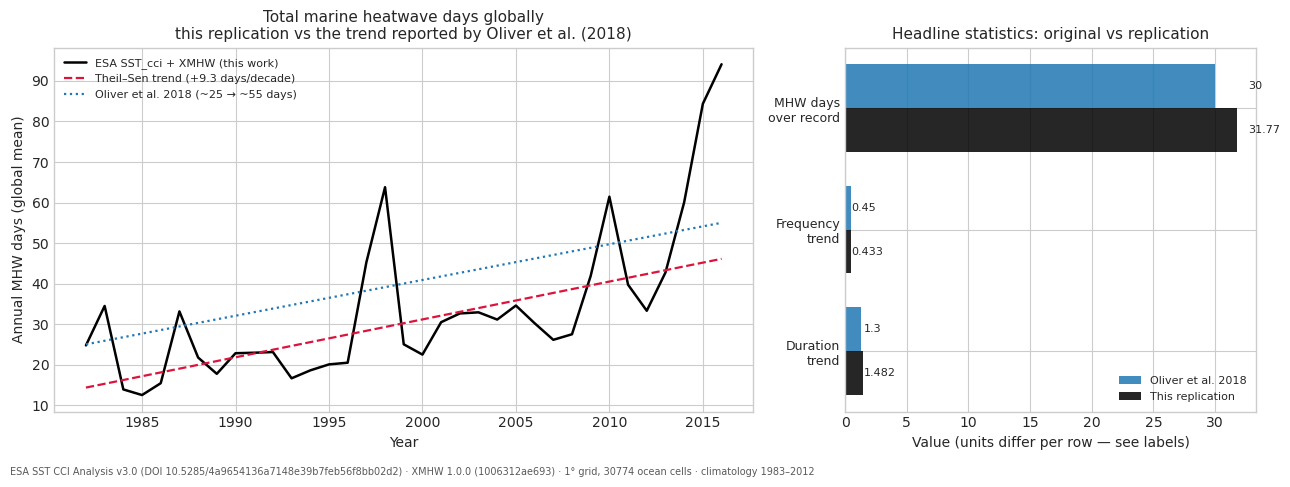

In [3]:
fig, (ax, ax2) = plt.subplots(
    1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.7, 1]}
)

# --- Panel A: the Figure 2 analogue -----------------------------------------
ax.plot(years, days, color="black", lw=1.8, label="ESA SST_cci + XMHW (this work)")

ok = np.isfinite(days)
slope, intercept, lo, hi = stats.theilslopes(days[ok], years[ok].astype(float), 0.95)
ax.plot(years, intercept + slope * years, color="crimson", lw=1.6, ls="--",
        label=f"Theil–Sen trend ({slope * 10:+.1f} days/decade)")

# Oliver et al.'s stated satellite-era endpoints, for reference.
o_base = cmp["mhw_days"]["original_baseline_1980s"]
o_end = o_base + cmp["mhw_days"]["original_change_over_record"]
ax.plot([years[0], years[-1]], [o_base, o_end], color="tab:blue", lw=1.6, ls=":",
        label=f"Oliver et al. 2018 (~{o_base:.0f} → ~{o_end:.0f} days)")

ax.set_xlabel("Year")
ax.set_ylabel("Annual MHW days (global mean)")
# Not "replication of Fig. 2" — notebook 07 holds that. This panel compares
# our series against the trend the original reports, which is a different claim.
ax.set_title("Total marine heatwave days globally\n"
             "this replication vs the trend reported by Oliver et al. (2018)",
             fontsize=11)
ax.legend(fontsize=8, loc="upper left")

# --- Panel B: headline statistics, original vs replication -------------------
metrics = [
    ("MHW days\nover record", cmp["mhw_days"]["original_change_over_record"],
     cmp["mhw_days"]["replication_change_over_record"], "days"),
    ("Frequency\ntrend", cmp["mhw_frequency"]["original_trend_per_decade"],
     cmp["mhw_frequency"]["replication_trend_per_decade"], "events/decade"),
    ("Duration\ntrend", cmp["mhw_duration"]["original_trend_per_decade"],
     cmp["mhw_duration"]["replication_trend_per_decade"], "days/decade"),
]
y = np.arange(len(metrics))
h = 0.36
ax2.barh(y - h / 2, [m[1] for m in metrics], height=h,
         color="tab:blue", alpha=0.85, label="Oliver et al. 2018")
ax2.barh(y + h / 2, [m[2] for m in metrics], height=h,
         color="black", alpha=0.85, label="This replication")
for i, (_, orig, repl, unit) in enumerate(metrics):
    ax2.text(max(orig, repl) * 1.03, i - h / 2, f"{orig:g}", va="center", fontsize=8)
    ax2.text(max(orig, repl) * 1.03, i + h / 2, f"{repl:g}", va="center", fontsize=8)
ax2.set_yticks(y)
ax2.set_yticklabels([m[0] for m in metrics], fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel("Value (units differ per row — see labels)")
ax2.set_title("Headline statistics: original vs replication", fontsize=11)
ax2.legend(fontsize=8, loc="lower right")

# Provenance comes from the comparison JSON that 03 wrote, never from literals
# here. This footer used to hardcode "XMHW (DOI 10.5281/zenodo.7662469)", which
# is version 0.9.2's DOI, while the pipeline runs 1.0.0 — so the headline figure
# asserted it was produced by software the replication never used. Naming the
# version and the SWHID keeps the figure honest even when separated from the
# repo, which is exactly what happens to figures.
prov = cmp["replication"]
n_cells = prov["n_cells"]
sw = f"XMHW {prov.get('software_version', '?')}"
swhid = prov.get("software_swhid", "")
sw_rev = swhid.split(";")[0].replace("swh:1:rev:", "")[:12] if swhid else ""
fig.suptitle("", y=0.99)
fig.text(0.01, 0.01,
         f"ESA SST CCI Analysis v3.0 (DOI {prov['dataset_doi']}) · "
         f"{sw}{f' ({sw_rev})' if sw_rev else ''} · {TARGET_RES_DEG:g}° grid, "
         f"{n_cells} ocean cells · climatology "
         f"{prov['climatology_period'][0]}–{prov['climatology_period'][1]}",
         fontsize=7, color="0.35")

# A partial run's figure is visually indistinguishable from the real one, and
# a figure outlives the shell that made it. Stamp it so it cannot be quoted by
# mistake.
if not IS_FULL_REPLICATION:
    fig.text(
        0.5, 0.5,
        f"SMOKE RUN — NOT THE REPLICATION RESULT\n"
        f"{TARGET_RES_DEG:g}° grid, every {LON_BAND_STRIDE}th longitude band",
        ha="center", va="center", fontsize=20, color="crimson",
        alpha=0.28, rotation=24, weight="bold", zorder=10,
    )

fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

## Spatial diagnostic

Not in the original Figure 2, but it shows *where* the global trend comes from
and makes a hemispheric artefact immediately visible if one exists.

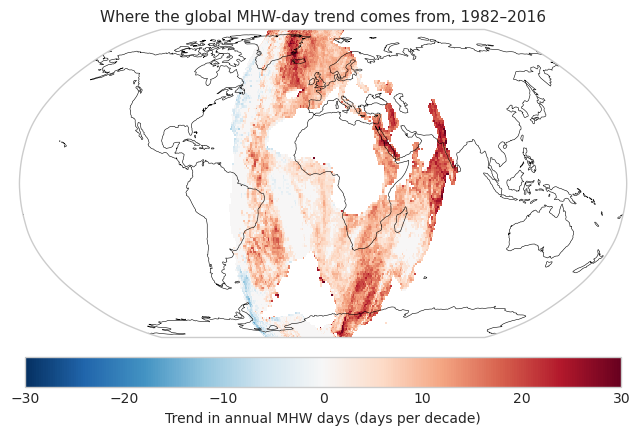

In [4]:
try:
    import cartopy.crs as ccrs

    trend = xr.apply_ufunc(
        lambda v: stats.theilslopes(v, years.astype(float))[0] * 10
        if np.isfinite(v).sum() > 10 else np.nan,
        res["mhw_days"],
        input_core_dims=[["year"]],
        vectorize=True,
        output_dtypes=[float],
    )

    fig2 = plt.figure(figsize=(11, 5))
    axm = plt.axes(projection=ccrs.Robinson())
    p = trend.plot(
        ax=axm, transform=ccrs.PlateCarree(), cmap="RdBu_r",
        vmin=-30, vmax=30, add_colorbar=False,
    )
    axm.coastlines(linewidth=0.4)
    axm.set_global()
    cb = fig2.colorbar(p, ax=axm, orientation="horizontal", pad=0.05, shrink=0.7)
    cb.set_label("Trend in annual MHW days (days per decade)")
    axm.set_title("Where the global MHW-day trend comes from, 1982–2016", fontsize=11)
    fig2.savefig(FIG_DIR / "mhw_days_trend_map.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as exc:  # cartopy is optional for the headline result
    print(f"skipped map: {exc}")